Exp 6: Credit Risk Assessment: Build a credit scoring model to assess the creditworthiness of applicants using historical financial data and perform comparative analysis (Logistic Regression, Random Forest, XGBoost)

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report


In [2]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/AIML_LAB/Exp 5_6_7_8/credit_risk_assessment_500_samples.csv")

# Check columns
print(df.columns)
print(df.head())

Index(['Applicant_ID', 'Age', 'Annual_Income', 'Employment_Years',
       'Credit_Score', 'Loan_Amount', 'Loan_Term_Months',
       'Existing_Loans_Count', 'Debt_to_Income_Ratio',
       'Late_Payments_Last_2Yrs', 'Credit_Risk'],
      dtype='object')
   Applicant_ID  Age  Annual_Income  Employment_Years  Credit_Score  \
0             1   59         153267                28           818   
1             2   49         232745                 0           436   
2             3   35         974945                19           797   
3             4   63         307164                29           776   
4             5   28         685626                 6           893   

   Loan_Amount  Loan_Term_Months  Existing_Loans_Count  Debt_to_Income_Ratio  \
0       196649                12                     2                  0.68   
1       175354                60                     0                  0.23   
2       662297                48                     3                  0.54   
3

In [3]:

X = df.drop(columns=['Credit_Risk'])


y = df['Credit_Risk']


encoder = LabelEncoder()
y = encoder.fit_transform(y)

print("Classes:", encoder.classes_)

Classes: ['High' 'Low' 'Medium']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
df.head()

,Applicant_ID,Age,Annual_Income,Employment_Years,Credit_Score,Loan_Amount,Loan_Term_Months,Existing_Loans_Count,Debt_to_Income_Ratio,Late_Payments_Last_2Yrs,Credit_Risk
0,1,59,153267,28,818,196649,12,2,0.68,0,High
1,2,49,232745,0,436,175354,60,0,0.23,5,High
2,3,35,974945,19,797,662297,48,3,0.54,0,Medium
3,4,63,307164,29,776,831725,48,0,0.56,4,High
4,5,28,685626,6,893,498625,60,3,0.66,8,High


In [5]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
df.head()

,Applicant_ID,Age,Annual_Income,Employment_Years,Credit_Score,Loan_Amount,Loan_Term_Months,Existing_Loans_Count,Debt_to_Income_Ratio,Late_Payments_Last_2Yrs,Credit_Risk
0,1,59,153267,28,818,196649,12,2,0.68,0,High
1,2,49,232745,0,436,175354,60,0,0.23,5,High
2,3,35,974945,19,797,662297,48,3,0.54,0,Medium
3,4,63,307164,29,776,831725,48,0,0.56,4,High
4,5,28,685626,6,893,498625,60,3,0.66,8,High


In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}
df.head()

,Applicant_ID,Age,Annual_Income,Employment_Years,Credit_Score,Loan_Amount,Loan_Term_Months,Existing_Loans_Count,Debt_to_Income_Ratio,Late_Payments_Last_2Yrs,Credit_Risk
0,1,59,153267,28,818,196649,12,2,0.68,0,High
1,2,49,232745,0,436,175354,60,0,0.23,5,High
2,3,35,974945,19,797,662297,48,3,0.54,0,Medium
3,4,63,307164,29,776,831725,48,0,0.56,4,High
4,5,28,685626,6,893,498625,60,3,0.66,8,High


In [7]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name} Results:\n", classification_report(y_test, y_pred, target_names=encoder.classes_))


Logistic Regression Results:
               precision    recall  f1-score   support

        High       0.86      0.93      0.89        58
         Low       0.75      0.60      0.67         5
      Medium       0.82      0.73      0.77        37

    accuracy                           0.84       100
   macro avg       0.81      0.75      0.78       100
weighted avg       0.84      0.84      0.84       100


Random Forest Results:
               precision    recall  f1-score   support

        High       1.00      1.00      1.00        58
         Low       1.00      0.80      0.89         5
      Medium       0.97      1.00      0.99        37

    accuracy                           0.99       100
   macro avg       0.99      0.93      0.96       100
weighted avg       0.99      0.99      0.99       100



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:28:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Results:
               precision    recall  f1-score   support

        High       1.00      1.00      1.00        58
         Low       1.00      1.00      1.00         5
      Medium       1.00      1.00      1.00        37

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100




Logistic Regression Results:
               precision    recall  f1-score   support

        High       0.86      0.93      0.89        58
         Low       0.75      0.60      0.67         5
      Medium       0.82      0.73      0.77        37

    accuracy                           0.84       100
   macro avg       0.81      0.75      0.78       100
weighted avg       0.84      0.84      0.84       100



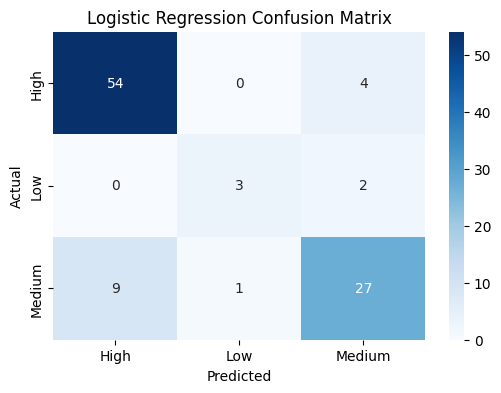


Random Forest Results:
               precision    recall  f1-score   support

        High       1.00      1.00      1.00        58
         Low       1.00      0.60      0.75         5
      Medium       0.95      1.00      0.97        37

    accuracy                           0.98       100
   macro avg       0.98      0.87      0.91       100
weighted avg       0.98      0.98      0.98       100



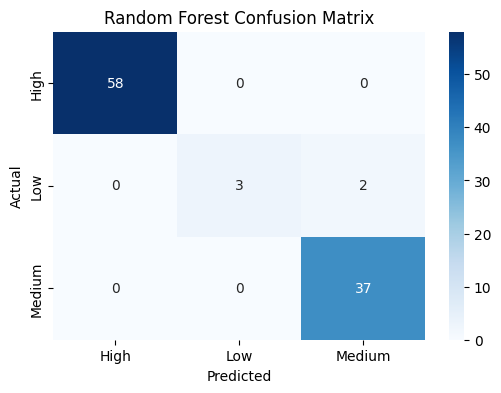


XGBoost Results:
               precision    recall  f1-score   support

        High       1.00      1.00      1.00        58
         Low       1.00      1.00      1.00         5
      Medium       1.00      1.00      1.00        37

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:28:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


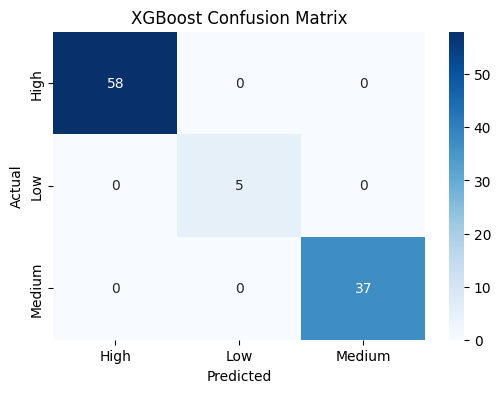

In [8]:

# Train and evaluate models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name} Results:\n", classification_report(y_test, y_pred, target_names=encoder.classes_))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot confusion matrix with seaborn
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=encoder.classes_,
                yticklabels=encoder.classes_)
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [11]:


# create models
LR = LogisticRegression()
NB = GaussianNB()
DT = DecisionTreeClassifier()
RF = RandomForestClassifier()
svc = SVC()

# train models (important)
LR.fit(X_train, y_train)
NB.fit(X_train, y_train)
DT.fit(X_train, y_train)
RF.fit(X_train, y_train)
svc.fit(X_train, y_train)

# save models
with open('/content/drive/MyDrive/AIML_LAB/Exp 5_6_7_8/s.model_Exp_8/logistic.pkl', 'wb') as f:
    pickle.dump(LR, f)

with open('/content/drive/MyDrive/AIML_LAB/Exp 5_6_7_8/s.model_Exp_8/naivebayes.pkl', 'wb') as f:
    pickle.dump(NB, f)

with open('/content/drive/MyDrive/AIML_LAB/Exp 5_6_7_8/s.model_Exp_8/decisiontree.pkl', 'wb') as f:
    pickle.dump(DT, f)

with open('/content/drive/MyDrive/AIML_LAB/Exp 5_6_7_8/s.model_Exp_8/randomforest.pkl', 'wb') as f:
    pickle.dump(RF, f)

with open('/content/drive/MyDrive/AIML_LAB/Exp 5_6_7_8/s.model_Exp_8/supportvector.pkl', 'wb') as f:
    pickle.dump(svc, f)

NameError: name 'GaussianNB' is not defined